# 02 — Preprocessing
## DENTEX Dataset — Resize, Format Conversion, and Dataset Preparation

**Student:** Shree Ramji | ec25075@qmul.ac.uk  
**Dataset:** DENTEX (MICCAI 2023)  

### Objectives of this notebook:
1. Load official DENTEX train/val/test split (678/46/242 images)
2. Assign each image to its dominant disease class (for CNN ImageFolder)
3. Resize images with letterboxing — CNN (224×224) and YOLO (640×640)
4. Save CNN images in class subfolders (raw pixels — normalisation applied during training)
5. Convert COCO JSON annotations → YOLO format (.txt label files)
6. Write dataset.yaml for YOLOv8
7. Verify CNN folder structure and YOLO bounding boxes
8. Document class weights for training

### Key decisions:
- Official DENTEX split used — results directly comparable to HierarchicalDet baseline
- Letterboxing preserves 2:1 panoramic aspect ratio — prevents tooth distortion
- Normalisation applied on-the-fly via PyTorch transforms in training notebook
- Augmentation applied on-the-fly in training notebook — not pre-saved to disk
- Each image assigned to dominant disease class (most frequent annotation per image)

## 1. Install Dependencies

In [1]:
!pip install albumentations scikit-learn pycocotools pyyaml -q
print("✓ Dependencies installed")

✓ Dependencies installed


## 2. Seed and Imports

In [2]:
import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)
print("Seed set to 42 ✓")

import json
import shutil
import yaml
import cv2
from pathlib import Path
from collections import Counter, defaultdict
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

[HAMI-core Msg(527:140705843703104:libvgpu.c:839)]: Initializing.....


Seed set to 42 ✓
PyTorch : 2.9.1+cu128
CUDA    : True
GPU     : NVIDIA A100 80GB PCIe


[HAMI-core Msg(527:140705843703104:libvgpu.c:855)]: Initialized


## 3. Define Paths and Constants

In [3]:
# Input paths
data_root = Path("./data/DENTEX/DENTEX")

# Training annotation
train_anno_path = data_root / "training_data" / "quadrant-enumeration-disease" / "train_quadrant_enumeration_disease.json"
train_img_dir   = data_root / "training_data" / "quadrant-enumeration-disease" / "xrays"

# Validation annotation
val_anno_path   = data_root / "validation_triple.json"
val_img_dir     = data_root / "validation_data" / "quadrant_enumeration_disease" / "xrays"

# Test images and labels
test_img_dir    = data_root / "disease" / "input"
test_label_dir  = data_root / "disease" / "label"

# Output paths
processed_root  = Path("./data/processed")

# CNN output — class subfolders
cnn_root = processed_root / "cnn"

# YOLO output
yolo_root = processed_root / "yolo"

# Constants
CNN_SIZE  = 224
YOLO_SIZE = 640

# Disease class mapping
DISEASE_NAMES = {
    0: 'Impacted',
    1: 'Caries',
    2: 'Periapical_Lesion',
    3: 'Deep_Caries'
}

print("Input paths:")
print(f"  Train annotations : {train_anno_path}")
print(f"  Train images      : {train_img_dir}")
print(f"  Val annotations   : {val_anno_path}")
print(f"  Val images        : {val_img_dir}")
print(f"  Test images       : {test_img_dir}")
print(f"  Test labels       : {test_label_dir}")
print(f"\nOutput paths:")
print(f"  CNN  : {cnn_root}")
print(f"  YOLO : {yolo_root}")
print(f"\nConstants:")
print(f"  CNN size  : {CNN_SIZE}x{CNN_SIZE}")
print(f"  YOLO size : {YOLO_SIZE}x{YOLO_SIZE}")

Input paths:
  Train annotations : data/DENTEX/DENTEX/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json
  Train images      : data/DENTEX/DENTEX/training_data/quadrant-enumeration-disease/xrays
  Val annotations   : data/DENTEX/DENTEX/validation_triple.json
  Val images        : data/DENTEX/DENTEX/validation_data/quadrant_enumeration_disease/xrays
  Test images       : data/DENTEX/DENTEX/disease/input
  Test labels       : data/DENTEX/DENTEX/disease/label

Output paths:
  CNN  : data/processed/cnn
  YOLO : data/processed/yolo

Constants:
  CNN size  : 224x224
  YOLO size : 640x640


## 4. Load Official DENTEX Annotations
Loading train, val, and test annotations separately.
Using the official DENTEX split for direct comparability with HierarchicalDet baseline.

Note on test labels: DENTEX test labels are per-image LabelMe JSON files with
Turkish disease names. A parser is used to convert them to standard class IDs.

Note on unrecognised test labels:
- `saglam` — healthy tooth (no disease) — excluded, outside 4-class scope
- `çekim` — extraction site — excluded, treatment label not diagnosis
- `küretaj` — curettage — excluded, treatment label not diagnosis
- `kırık` — fracture — excluded, not in DENTEX 4 disease classes

In [4]:
# Load train annotations
with open(train_anno_path) as f:
    train_annotations = json.load(f)

# Load val annotations
with open(val_anno_path) as f:
    val_annotations = json.load(f)

# Find annotated image IDs only
def get_annotated_ids(annotations):
    annotated_ids = set(ann['image_id'] for ann in annotations['annotations'])
    return annotated_ids

train_annotated_ids = get_annotated_ids(train_annotations)
val_annotated_ids   = get_annotated_ids(val_annotations)

print(f"Train — total: {len(train_annotations['images'])} | annotated: {len(train_annotated_ids)} | excluded: {len(train_annotations['images']) - len(train_annotated_ids)}")
print(f"Val   — total: {len(val_annotations['images'])}   | annotated: {len(val_annotated_ids)}   | excluded: {len(val_annotations['images']) - len(val_annotated_ids)}")

Train — total: 705 | annotated: 678 | excluded: 27
Val   — total: 50   | annotated: 46   | excluded: 4


In [5]:
def parse_turkish_label(label_str):
    """
    Parse LabelMe Turkish label string → disease class id.
    Format: '{prefix}-{disease_name}-{tooth_number}'
    
    Turkish disease names:
      gömülü        → 0 Impacted
      çürük         → 1 Caries (must check 'derin çürük' first)
      derin çürük   → 3 Deep Caries
      periapikal    → 2 Periapical Lesion
    
    Returns None for non-disease labels (saglam, çekim, küretaj)
    """
    label_str = label_str.lower()
    if ('derin' in label_str or 'derin_' in label_str) and 'çürük' in label_str:
        return 3  # Deep Caries
    elif 'çürük' in label_str or 'curuk' in label_str:
        return 1  # Caries
    elif 'gömülü' in label_str or 'gomulu' in label_str or 'impacted' in label_str:
        return 0  # Impacted
    elif 'periapikal' in label_str or 'periapical' in label_str or 'kanal' in label_str or 'lezyon' in label_str:
        return 2  # Periapical Lesion
    else:
        return None  # saglam, çekim, küretaj, kırık — healthy or treatment labels

# Load all test labels
test_data = {}       # image_stem → list of {class_id, bbox}
unrecognised = set()
skipped_count = 0

for label_file in sorted(test_label_dir.glob("*.json")):
    with open(label_file) as f:
        label_json = json.load(f)

    img_stem = label_file.stem  # e.g. 'test_0'
    annotations_list = []

    for shape in label_json.get('shapes', []):
        disease_id = parse_turkish_label(shape['label'])
        if disease_id is None:
            unrecognised.add(shape['label'])
            continue

        # LabelMe polygon → bounding box
        points = shape['points']
        xs = [p[0] for p in points]
        ys = [p[1] for p in points]
        x1, y1 = min(xs), min(ys)
        x2, y2 = max(xs), max(ys)
        bbox = [x1, y1, x2 - x1, y2 - y1]  # COCO format: x,y,w,h

        annotations_list.append({
            'class_id': disease_id,
            'bbox': bbox
        })

    if annotations_list:
        test_data[img_stem] = annotations_list
    else:
        skipped_count += 1

print(f"Test images with disease annotations : {len(test_data)}")
print(f"Test images skipped (no disease)     : {skipped_count}")
print(f"\nUnrecognised labels excluded: {unrecognised}")

Test images with disease annotations : 242
Test images skipped (no disease)     : 8

Unrecognised labels excluded: {'0-saglam-44', '0-saglam-22', '0-saglam-34', '5-çekim-34', '0-saglam-26', '2-küretaj-46', '5-çekim-22', '5-çekim-38', '2-küretaj-36', '0-saglam-33', '0-saglam-48', '0-saglam-46', '5-çekim-46', '8-kırık-11', '8-kırık-31', '0-saglam-36', '5-çekim-44', '8-kırık-33', '0-saglam-31', '0-saglam-14', '0-saglam-47', '0-saglam-25', '2-küretaj-33', '2-küretaj-21', '2-küretaj-18', '0-saglam-24', '0-saglam-17', '0-saglam-27', '0-saglam-28', '0-saglam-41', '0-saglam-32', '0-saglam-12', '2-küretaj-35', '2-küretaj-17', '2-küretaj-42', '5-çekim-15', '0-saglam-15', '2-küretaj-26', '2-küretaj-11', '0-saglam-16', '8-kırık-42', '5-çekim-45', '5-çekim-47', '8-kırık-22', '0-saglam-43', '0-saglam-11', '5-çekim-18', '2-küretaj-45', '0-saglam-21', '2-küretaj-15', '2-küretaj-27', '0-saglam-18', '2-küretaj-37', '0-saglam-23', '5-çekim-36', '5-çekim-27', '2-küretaj-12', '5-çekim-48', '8-kırık-13', '2

## 5. Assign Dominant Disease Class to Each Image
For CNN classification, each image needs a single class label.
Images with multiple disease annotations are assigned to their
most frequent disease class (dominant class strategy).

This is required for PyTorch ImageFolder which expects one class per image.
For localisation (YOLO), all annotations are kept — no dominant class needed.

In [6]:
def get_dominant_class(annotations, annotated_ids, id_key='category_id_3'):
    """
    For each image, find the most frequent disease class.
    Returns dict: {image_id: dominant_class_id}
    """
    image_disease_counts = defaultdict(Counter)
    
    for ann in annotations['annotations']:
        if ann['image_id'] in annotated_ids:
            image_disease_counts[ann['image_id']][ann[id_key]] += 1
    
    dominant = {}
    for image_id, counts in image_disease_counts.items():
        dominant[image_id] = max(counts, key=counts.get)
    
    return dominant

# Get dominant class per image for train and val
train_dominant = get_dominant_class(train_annotations, train_annotated_ids)
val_dominant   = get_dominant_class(val_annotations, val_annotated_ids)

# For test — dominant class from parsed labels
test_dominant = {}
for img_stem, anns in test_data.items():
    counts = Counter(ann['class_id'] for ann in anns)
    test_dominant[img_stem] = max(counts, key=counts.get)

# Print distribution
print("Dominant class distribution:")
print(f"\n{'Disease':<25} {'Train':>8} {'Val':>6} {'Test':>6}")
print("-" * 48)
train_cls_counts = Counter(train_dominant.values())
val_cls_counts   = Counter(val_dominant.values())
test_cls_counts  = Counter(test_dominant.values())

for cls_id, cls_name in DISEASE_NAMES.items():
    t = train_cls_counts.get(cls_id, 0)
    v = val_cls_counts.get(cls_id, 0)
    te = test_cls_counts.get(cls_id, 0)
    print(f"  {cls_name:<23} {t:>8} {v:>6} {te:>6}")

print(f"\n  {'TOTAL':<23} {sum(train_cls_counts.values()):>8} {sum(val_cls_counts.values()):>6} {sum(test_cls_counts.values()):>6}")

Dominant class distribution:

Disease                      Train    Val   Test
------------------------------------------------
  Impacted                     116      9     42
  Caries                       476     27    163
  Periapical_Lesion             16      2     37
  Deep_Caries                   70      8      0

  TOTAL                        678     46    242


## 6. Create Output Directory Structure
Creating CNN (class subfolders) and YOLO (images + labels) folder structure.

In [7]:
# CNN — class subfolders per split
for split in ['train', 'val', 'test']:
    for cls_name in DISEASE_NAMES.values():
        (cnn_root / split / cls_name).mkdir(parents=True, exist_ok=True)

# YOLO — images and labels per split
for split in ['train', 'val', 'test']:
    (yolo_root / split / 'images').mkdir(parents=True, exist_ok=True)
    (yolo_root / split / 'labels').mkdir(parents=True, exist_ok=True)

print("CNN folder structure:")
for split in ['train', 'val', 'test']:
    for cls_name in DISEASE_NAMES.values():
        print(f"  cnn/{split}/{cls_name}/")

print("\nYOLO folder structure:")
for split in ['train', 'val', 'test']:
    print(f"  yolo/{split}/images/")
    print(f"  yolo/{split}/labels/")

CNN folder structure:
  cnn/train/Impacted/
  cnn/train/Caries/
  cnn/train/Periapical_Lesion/
  cnn/train/Deep_Caries/
  cnn/val/Impacted/
  cnn/val/Caries/
  cnn/val/Periapical_Lesion/
  cnn/val/Deep_Caries/
  cnn/test/Impacted/
  cnn/test/Caries/
  cnn/test/Periapical_Lesion/
  cnn/test/Deep_Caries/

YOLO folder structure:
  yolo/train/images/
  yolo/train/labels/
  yolo/val/images/
  yolo/val/labels/
  yolo/test/images/
  yolo/test/labels/


## 7. Letterbox Resize Function
Letterboxing resizes the image keeping its original aspect ratio,
then pads the shorter dimension with black pixels to reach the target size.

This is critical for panoramic dental X-rays which have a 2:1 aspect ratio.
Naive square resize would squish teeth horizontally, distorting anatomy
and harming model performance.

The padding offset is also returned for YOLO — needed to correctly
shift bounding box coordinates after padding.

Original image size : (2830, 1316)
After 224 letterbox : (224, 224) | scale=0.0792 | pad_left=0 pad_top=60
After 640 letterbox : (640, 640) | scale=0.2261 | pad_left=0 pad_top=171


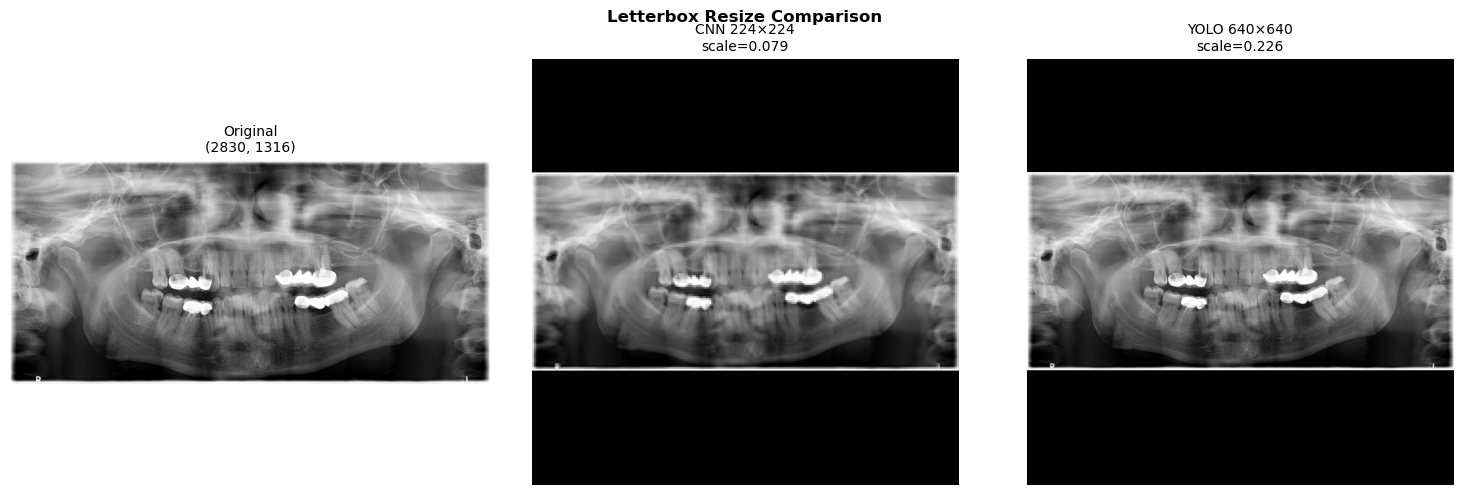

✓ Letterbox function verified


In [8]:
def letterbox_resize(img_path, target_size):
    """
    Resize image to target_size x target_size using letterboxing.
    Returns:
        img_resized : PIL Image (target_size x target_size, RGB)
        scale       : float — scaling factor applied to original
        pad_left    : int — pixels padded on left
        pad_top     : int — pixels padded on top
    """
    img = Image.open(img_path).convert("RGB")
    orig_w, orig_h = img.size

    # Scale to fit inside target square keeping aspect ratio
    scale = min(target_size / orig_w, target_size / orig_h)
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)

    # Resize
    img_resized = img.resize((new_w, new_h), Image.LANCZOS)

    # Pad to square with black
    pad_left = (target_size - new_w) // 2
    pad_top  = (target_size - new_h) // 2

    img_padded = Image.new("RGB", (target_size, target_size), (0, 0, 0))
    img_padded.paste(img_resized, (pad_left, pad_top))

    return img_padded, scale, pad_left, pad_top

# Test on one image
sample_path = list(train_img_dir.glob("*.png"))[0]
img_224, scale_224, pl_224, pt_224 = letterbox_resize(sample_path, CNN_SIZE)
img_640, scale_640, pl_640, pt_640 = letterbox_resize(sample_path, YOLO_SIZE)

print(f"Original image size : {Image.open(sample_path).size}")
print(f"After 224 letterbox : {img_224.size} | scale={scale_224:.4f} | pad_left={pl_224} pad_top={pt_224}")
print(f"After 640 letterbox : {img_640.size} | scale={scale_640:.4f} | pad_left={pl_640} pad_top={pt_640}")

# Visualise letterboxing
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(Image.open(sample_path), cmap='gray')
axes[0].set_title(f"Original\n{Image.open(sample_path).size}", fontsize=10)
axes[1].imshow(img_224, cmap='gray')
axes[1].set_title(f"CNN 224×224\nscale={scale_224:.3f}", fontsize=10)
axes[2].imshow(img_640, cmap='gray')
axes[2].set_title(f"YOLO 640×640\nscale={scale_640:.3f}", fontsize=10)
for ax in axes:
    ax.axis('off')
plt.suptitle("Letterbox Resize Comparison", fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/eda/letterbox_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Letterbox function verified")

## 8. Save CNN Images (224×224 with class subfolders)
Each image saved to its dominant disease class subfolder.
Raw pixel values saved — ImageNet normalisation applied during training via transforms.

In [9]:
def save_cnn_split(split_name, img_dir, dominant_class_map,
                   annotations_obj=None, annotated_ids=None,
                   test_data_dict=None):
    """
    Save resized images into CNN class subfolders for one split.
    """
    saved = Counter()
    skipped = 0

    if split_name == 'test':
        # Test — use img_stem directly
        for img_stem, cls_id in dominant_class_map.items():
            img_path = img_dir / f"{img_stem}.png"
            if not img_path.exists():
                skipped += 1
                continue
            cls_name = DISEASE_NAMES[cls_id]
            out_path = cnn_root / split_name / cls_name / f"{img_stem}.png"
            img_resized, _, _, _ = letterbox_resize(img_path, CNN_SIZE)
            img_resized.save(out_path)
            saved[cls_name] += 1
    else:
        # Train/val — use image_id from annotations
        id_to_filename = {img['id']: img['file_name']
                          for img in annotations_obj['images']}
        for img_id, cls_id in dominant_class_map.items():
            fname = id_to_filename.get(img_id)
            if not fname:
                skipped += 1
                continue
            img_path = img_dir / fname
            if not img_path.exists():
                skipped += 1
                continue
            cls_name = DISEASE_NAMES[cls_id]
            out_path = cnn_root / split_name / cls_name / fname
            img_resized, _, _, _ = letterbox_resize(img_path, CNN_SIZE)
            img_resized.save(out_path)
            saved[cls_name] += 1

    print(f"\n  {split_name.upper()} saved:")
    for cls_name in DISEASE_NAMES.values():
        print(f"    {cls_name:<25} {saved.get(cls_name, 0):>5} images")
    print(f"    {'TOTAL':<25} {sum(saved.values()):>5} images")
    if skipped:
        print(f"    Skipped: {skipped}")
    return saved

print("Saving CNN images...")
print("=" * 50)

train_saved = save_cnn_split('train', train_img_dir,
                              train_dominant, train_annotations,
                              train_annotated_ids)

val_saved = save_cnn_split('val', val_img_dir,
                            val_dominant, val_annotations,
                            val_annotated_ids)

test_saved = save_cnn_split('test', test_img_dir,
                             test_dominant,
                             test_data_dict=test_data)

print("\n✓ CNN preprocessing complete")

Saving CNN images...

  TRAIN saved:
    Impacted                    116 images
    Caries                      476 images
    Periapical_Lesion            16 images
    Deep_Caries                  70 images
    TOTAL                       678 images

  VAL saved:
    Impacted                      9 images
    Caries                       27 images
    Periapical_Lesion             2 images
    Deep_Caries                   8 images
    TOTAL                        46 images

  TEST saved:
    Impacted                     42 images
    Caries                      163 images
    Periapical_Lesion            37 images
    Deep_Caries                   0 images
    TOTAL                       242 images

✓ CNN preprocessing complete


## 9. Verify CNN Folder Structure
Confirming images are correctly saved in class subfolders.
PyTorch ImageFolder requires this exact structure.

In [10]:
print("CNN folder structure verification:")
print("=" * 50)
for split in ['train', 'val', 'test']:
    print(f"\n  {split}/")
    total = 0
    for cls_name in DISEASE_NAMES.values():
        count = len(list((cnn_root / split / cls_name).glob('*.png')))
        print(f"    {cls_name:<25} {count:>5} images")
        total += count
    print(f"    {'TOTAL':<25} {total:>5} images")

# Verify a sample image is correct size
sample = list((cnn_root / 'train' / 'Caries').glob('*.png'))[0]
img = Image.open(sample)
print(f"\nSample image size: {img.size} (should be {CNN_SIZE}x{CNN_SIZE})")
print(f"Sample image mode: {img.mode} (should be RGB)")
print("\n✓ CNN structure verified — ready for PyTorch ImageFolder")

CNN folder structure verification:

  train/
    Impacted                    116 images
    Caries                      476 images
    Periapical_Lesion            16 images
    Deep_Caries                  70 images
    TOTAL                       678 images

  val/
    Impacted                      9 images
    Caries                       27 images
    Periapical_Lesion             2 images
    Deep_Caries                   8 images
    TOTAL                        46 images

  test/
    Impacted                     42 images
    Caries                      163 images
    Periapical_Lesion            37 images
    Deep_Caries                   0 images
    TOTAL                       242 images

Sample image size: (224, 224) (should be 224x224)
Sample image mode: RGB (should be RGB)

✓ CNN structure verified — ready for PyTorch ImageFolder


## 10. COCO JSON → YOLO Format Conversion
YOLO expects one .txt file per image where each line is:
`class_id cx cy w h` — all values normalised 0–1.

COCO format: [x_top_left, y_top_left, width, height] in pixels
YOLO format: [cx, cy, w, h] normalised by image dimensions

After letterboxing, bounding box coordinates must be adjusted:
1. Scale original pixel coords by the letterbox scale factor
2. Add the padding offset (pad_left, pad_top)
3. Normalise by YOLO_SIZE

In [11]:
def coco_to_yolo(bbox, orig_w, orig_h, scale, pad_left, pad_top, yolo_size):
    """
    Convert COCO bbox to YOLO normalised format after letterboxing.
    
    Args:
        bbox      : [x, y, w, h] in original image pixel coordinates
        orig_w/h  : original image dimensions
        scale     : letterbox scale factor
        pad_left  : left padding in pixels
        pad_top   : top padding in pixels
        yolo_size : target image size (640)
    
    Returns:
        [cx, cy, w, h] normalised 0-1
    """
    x, y, w, h = bbox

    # Scale coords to letterboxed image space
    x_scaled = x * scale + pad_left
    y_scaled = y * scale + pad_top
    w_scaled = w * scale
    h_scaled = h * scale

    # Convert to centre format
    cx = x_scaled + w_scaled / 2
    cy = y_scaled + h_scaled / 2

    # Normalise by image size
    cx /= yolo_size
    cy /= yolo_size
    w_scaled /= yolo_size
    h_scaled /= yolo_size

    # Clamp to [0, 1]
    cx = max(0, min(1, cx))
    cy = max(0, min(1, cy))
    w_scaled = max(0, min(1, w_scaled))
    h_scaled = max(0, min(1, h_scaled))

    return [cx, cy, w_scaled, h_scaled]

print("YOLO conversion function defined ✓")

YOLO conversion function defined ✓


In [12]:
# Index train annotations by image_id for fast lookup
train_ann_by_image = defaultdict(list)
for ann in train_annotations['annotations']:
    if ann['image_id'] in train_annotated_ids:
        train_ann_by_image[ann['image_id']].append(ann)

# Index val annotations by image_id
val_ann_by_image = defaultdict(list)
for ann in val_annotations['annotations']:
    if ann['image_id'] in val_annotated_ids:
        val_ann_by_image[ann['image_id']].append(ann)

print(f"Train annotation index: {len(train_ann_by_image)} images")
print(f"Val annotation index  : {len(val_ann_by_image)} images")

Train annotation index: 678 images
Val annotation index  : 46 images


In [13]:
def save_yolo_split_coco(split_name, img_dir, annotations_obj,
                          ann_by_image, annotated_ids):
    """
    Save YOLO images and labels for train or val split.
    Uses COCO JSON annotations.
    """
    id_to_filename = {img['id']: img['file_name']
                      for img in annotations_obj['images']}
    saved = 0
    skipped = 0

    for img_id in annotated_ids:
        fname = id_to_filename.get(img_id)
        if not fname:
            skipped += 1
            continue

        img_path = img_dir / fname
        if not img_path.exists():
            skipped += 1
            continue

        # Letterbox resize and save image
        img_resized, scale, pad_left, pad_top = letterbox_resize(img_path, YOLO_SIZE)
        out_img_path = yolo_root / split_name / 'images' / fname
        img_resized.save(out_img_path)

        # Get original dimensions
        orig_img = Image.open(img_path)
        orig_w, orig_h = orig_img.size

        # Write YOLO label file
        out_lbl_path = yolo_root / split_name / 'labels' / (Path(fname).stem + '.txt')
        with open(out_lbl_path, 'w') as f:
            for ann in ann_by_image[img_id]:
                cls_id = ann['category_id_3']
                bbox   = ann['bbox']
                cx, cy, w, h = coco_to_yolo(
                    bbox, orig_w, orig_h, scale, pad_left, pad_top, YOLO_SIZE
                )
                f.write(f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")
        saved += 1

    print(f"  YOLO {split_name:<5}: {saved} images saved | {skipped} skipped")
    return saved

print("Saving YOLO train and val...")
save_yolo_split_coco('train', train_img_dir, train_annotations,
                      train_ann_by_image, train_annotated_ids)
save_yolo_split_coco('val', val_img_dir, val_annotations,
                      val_ann_by_image, val_annotated_ids)
print("✓ YOLO train and val saved")

Saving YOLO train and val...
  YOLO train: 678 images saved | 0 skipped
  YOLO val  : 46 images saved | 0 skipped
✓ YOLO train and val saved


In [14]:
def save_yolo_split_test(test_img_dir, test_data):
    """
    Save YOLO images and labels for test split.
    Uses parsed Turkish LabelMe JSON annotations.
    """
    saved = 0
    skipped = 0

    for img_stem, anns in test_data.items():
        img_path = test_img_dir / f"{img_stem}.png"
        if not img_path.exists():
            skipped += 1
            continue

        # Letterbox resize and save image
        img_resized, scale, pad_left, pad_top = letterbox_resize(img_path, YOLO_SIZE)
        out_img_path = yolo_root / 'test' / 'images' / f"{img_stem}.png"
        img_resized.save(out_img_path)

        # Get original dimensions
        orig_img = Image.open(img_path)
        orig_w, orig_h = orig_img.size

        # Write YOLO label file
        out_lbl_path = yolo_root / 'test' / 'labels' / f"{img_stem}.txt"
        with open(out_lbl_path, 'w') as f:
            for ann in anns:
                cls_id = ann['class_id']
                bbox   = ann['bbox']
                cx, cy, w, h = coco_to_yolo(
                    bbox, orig_w, orig_h, scale, pad_left, pad_top, YOLO_SIZE
                )
                f.write(f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")
        saved += 1

    print(f"  YOLO test : {saved} images saved | {skipped} skipped")
    return saved

print("Saving YOLO test...")
save_yolo_split_test(test_img_dir, test_data)
print("✓ YOLO test saved")

Saving YOLO test...
  YOLO test : 242 images saved | 0 skipped
✓ YOLO test saved


## 11. Write dataset.yaml
YOLOv8 requires a configuration file pointing to image directories and class names.

In [15]:
dataset_yaml = {
    'path'  : str(yolo_root.resolve()),
    'train' : 'train/images',
    'val'   : 'val/images',
    'test'  : 'test/images',
    'nc'    : 4,
    'names' : ['Impacted', 'Caries', 'Periapical Lesion', 'Deep Caries']
}

yaml_path = yolo_root / 'dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, sort_keys=False)

print(f"Saved: {yaml_path}")
print("\nContents:")
with open(yaml_path) as f:
    print(f.read())

Saved: data/processed/yolo/dataset.yaml

Contents:
path: /home/jovyan/Master's Project/data/processed/yolo
train: train/images
val: val/images
test: test/images
nc: 4
names:
- Impacted
- Caries
- Periapical Lesion
- Deep Caries



## 12. Verify YOLO File Counts
Confirming image and label counts match across all splits.
A mismatch means some images have no label file — which causes YOLOv8 errors.

In [16]:
print("YOLO file count verification:")
print("=" * 55)
print(f"{'Split':<8} {'Images':>8} {'Labels':>8} {'Match':>8}")
print("-" * 55)
all_ok = True
for split in ['train', 'val', 'test']:
    n_images = len(list((yolo_root / split / 'images').glob('*.png')))
    n_labels = len(list((yolo_root / split / 'labels').glob('*.txt')))
    match = "✓" if n_images == n_labels else "⚠️ MISMATCH"
    if n_images != n_labels:
        all_ok = False
    print(f"  {split:<6} {n_images:>8} {n_labels:>8} {match:>8}")

if all_ok:
    print("\n✓ All splits verified — images and labels match")
else:
    print("\n⚠️ Mismatch detected — check missing label files")

YOLO file count verification:
Split      Images   Labels    Match
-------------------------------------------------------
  train       678      678        ✓
  val          46       46        ✓
  test        242      242        ✓

✓ All splits verified — images and labels match


## 13. Verify YOLO Bounding Boxes
Drawing converted bounding boxes back onto resized images to confirm
the COCO → YOLO conversion is geometrically correct.
Boxes should align with teeth and disease regions.

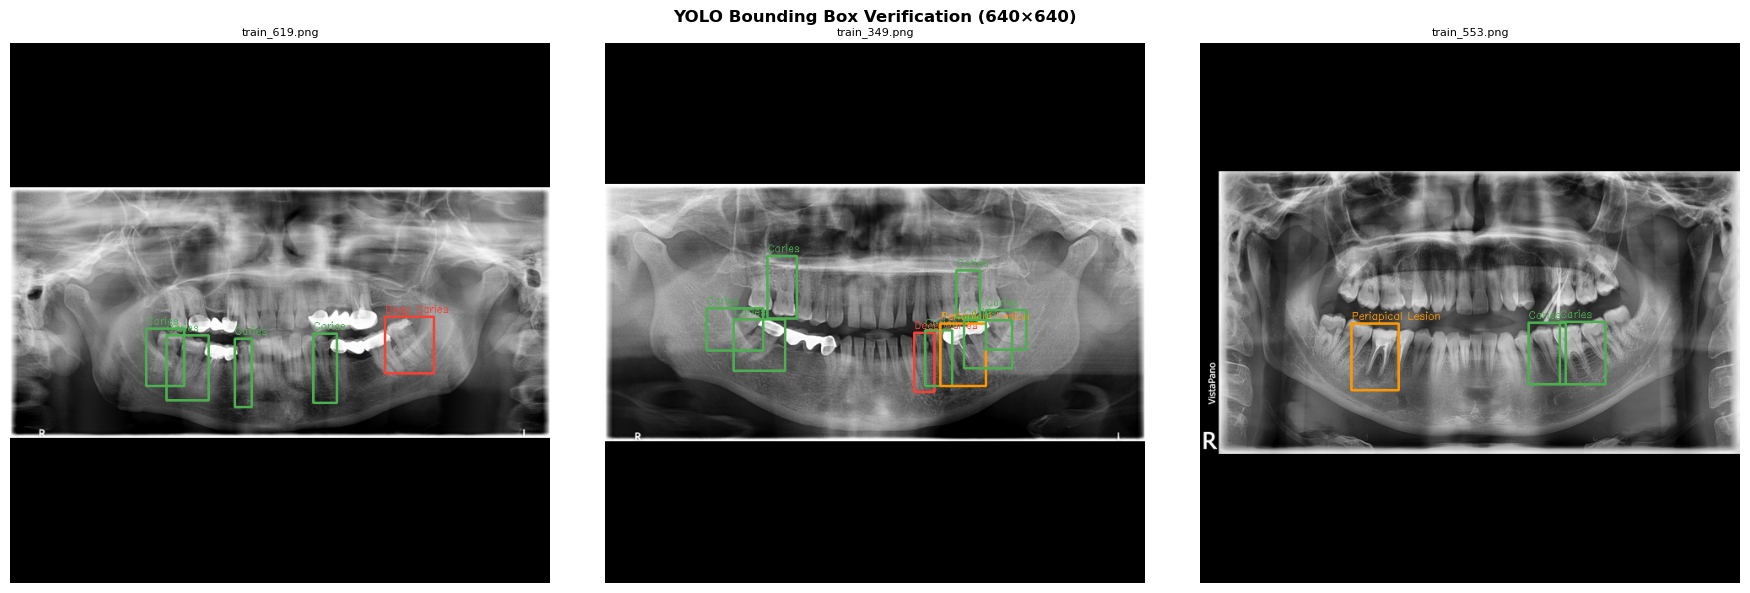

✓ Boxes should align with teeth/disease regions


In [17]:
import os
os.makedirs('./outputs/eda', exist_ok=True)

colors = {0: (33,150,243), 1: (76,175,80), 2: (255,152,0), 3: (244,67,54)}
label_names = {0:'Impacted', 1:'Caries', 2:'Periapical Lesion', 3:'Deep Caries'}

sample_imgs = list((yolo_root / 'train' / 'images').glob('*.png'))[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, img_path in zip(axes, sample_imgs):
    img = np.array(Image.open(img_path).convert("RGB"))
    label_path = yolo_root / 'train' / 'labels' / (img_path.stem + '.txt')

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:
        cls, cx, cy, nw, nh = map(float, line.strip().split())
        cls = int(cls)
        x1 = int((cx - nw/2) * YOLO_SIZE)
        y1 = int((cy - nh/2) * YOLO_SIZE)
        x2 = int((cx + nw/2) * YOLO_SIZE)
        y2 = int((cy + nh/2) * YOLO_SIZE)
        color = colors[cls]
        cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
        cv2.putText(img, label_names[cls], (x1, max(y1-5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

    ax.imshow(img)
    ax.set_title(img_path.name[:25], fontsize=8)
    ax.axis('off')

plt.suptitle("YOLO Bounding Box Verification (640×640)", fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/eda/yolo_bbox_verify.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Boxes should align with teeth/disease regions")

## 14. Class Weights for Training
Computed from training annotation counts using inverse frequency weighting.
These weights are passed to the loss function during CNN training to
address the significant class imbalance (14:1 Caries to Periapical ratio).

In [18]:
# Count training annotations per disease class
train_ann_counts = Counter()
for ann in train_annotations['annotations']:
    if ann['image_id'] in train_annotated_ids:
        train_ann_counts[ann['category_id_3']] += 1

total_anns  = sum(train_ann_counts.values())
num_classes = len(DISEASE_NAMES)

print("Class weights for training (inverse frequency):")
print("=" * 55)
print(f"{'Disease':<25} {'Annotations':>12} {'Weight':>10}")
print("-" * 55)

class_weights = {}
for cls_id, cls_name in DISEASE_NAMES.items():
    count  = train_ann_counts[cls_id]
    weight = total_anns / (num_classes * count)
    class_weights[cls_id] = round(weight, 4)
    print(f"  {cls_name:<23} {count:>12} {weight:>10.4f}")

print(f"\nTotal annotations: {total_anns}")
print(f"\nClass weights to use in training:")
print(f"  torch.tensor({list(class_weights.values())})")
print(f"\nInterpretation:")
print(f"  Weight > 1.0 → model penalised more for missing this class")
print(f"  Weight < 1.0 → model penalised less for missing this class")
print(f"  Periapical Lesion is {class_weights[2]:.1f}x more penalised than Caries")

Class weights for training (inverse frequency):
Disease                    Annotations     Weight
-------------------------------------------------------
  Impacted                         604     1.4607
  Caries                          2189     0.4030
  Periapical_Lesion                158     5.5839
  Deep_Caries                      578     1.5264

Total annotations: 3529

Class weights to use in training:
  torch.tensor([1.4607, 0.403, 5.5839, 1.5264])

Interpretation:
  Weight > 1.0 → model penalised more for missing this class
  Weight < 1.0 → model penalised less for missing this class
  Periapical Lesion is 5.6x more penalised than Caries


## Preprocessing Summary — Key Decisions for Dissertation

| Decision | Value | Reason |
|---|---|---|
| Split strategy | Official DENTEX split | Ensures comparability to HierarchicalDet baseline |
| Training images | 678 (27 excluded) | 27 unannotated images removed |
| Validation images | 46 (4 excluded) | 4 unannotated images removed |
| Test images | 242 (8 excluded) | 8 unannotated images removed |
| CNN input size | 224×224 | Required by ImageNet pre-trained weights |
| YOLO input size | 640×640 | YOLOv8 default — optimal speed/accuracy balance |
| Resize method | Letterboxing | Preserves 2:1 aspect ratio — prevents tooth distortion |
| Normalisation | On-the-fly via transforms | Raw pixels saved — flexible, standard PyTorch practice |
| Augmentation | On-the-fly in training notebook | Not pre-saved — prevents disk bloat, allows experimentation |
| Class labels (CNN) | Dominant disease per image | Required by PyTorch ImageFolder — one label per image |
| Class weights | Inverse frequency | Addresses 14:1 Caries/Periapical imbalance |
| Deep Caries test | 0 annotations | Known DENTEX limitation — evaluate on val set only |
| Unrecognised labels | Excluded | saglam/çekim/küretaj/kırık — healthy, treatment, or out-of-scope labels |

**Class weights for training loss function:**
- Impacted         : 1.4607
- Caries           : 0.4030  (majority — penalised less)
- Periapical Lesion: 5.5839  (minority — penalised most)
- Deep Caries      : 1.5264